# Chapter 8. 양자 커널을 이용한 비지도학습(Quantum Kernel Unsupervised Learning)

## 개요(Overview)

이 노트북에서는 양자 커널을 사용한 **비지도학습** 워크플로우를 다룬다. 양자 커널을 활용하여 데이터를 고차원 힐베르트 공간에 매핑한 후, 군집화(Clustering)와 커널 주성분 분석(Kernel PCA)을 수행한다.

양자 커널의 기본 개념과 지도학습(분류)에 대해서는 `ch07_quantum_kernel_Supervised.ipynb`를 참조하라.

**내용:**

1. [환경 설정](#1.-환경-설정)
2. [군집화](#2.-군집화(Clustering))
3. [커널 주성분 분석](#3.-커널-주성분-분석(Kernel-Principal-Component-Analysis))
4. [결론](#4.-결론(Conclusion))


## 1. 환경 설정

### 1.1. 양자 커널 개요

양자 커널은 양자 특성 맵(Feature Map)을 사용하여 데이터 포인트 간의 유사도를 측정한다. 양자 특성 맵 $\phi(x)$는 고전적 데이터 $x$를 양자 상태 $|\phi(x)\rangle$으로 변환하며, 커널 함수는 다음과 같이 정의된다:

$$ K(x_i, x_j) = |\langle\phi(x_i)|\phi(x_j)\rangle|^2 $$

이 커널 함수를 비지도학습 알고리즘(스펙트럼 군집화, 커널 PCA 등)에 적용하면, 양자 컴퓨터의 고차원 힐베르트 공간을 활용한 강력한 데이터 분석이 가능하다.

### 1.2. 라이브러리 임포트 및 설정


In [1]:
# 재현성을 위해 알고리즘 전역 시드를 설정한다(Set algorithm global seed for reproducibility)
from qiskit_machine_learning.utils import algorithm_globals

algorithm_globals.random_seed = 12345

In [3]:
# 데이터셋을 플롯하기 위한 유틸리티 함수들을 정의한다(Define utility functions to plot the dataset)
import matplotlib.pyplot as plt
import numpy as np


def plot_features(ax, features, labels, class_label, marker, face, edge, label):
    # A train plot
    ax.scatter(
        # x coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 0],
        # y coordinate of labels where class is class_label
        features[np.where(labels[:] == class_label), 1],
        marker=marker,
        facecolors=face,
        edgecolors=edge,
        label=label,
    )


def plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total):

    plt.figure(figsize=(5, 5))
    plt.ylim(0, 2 * np.pi)
    plt.xlim(0, 2 * np.pi)
    plt.imshow(
        np.asmatrix(adhoc_total).T,
        interpolation="nearest",
        origin="lower",
        cmap="RdBu",
        extent=[0, 2 * np.pi, 0, 2 * np.pi],
    )

    # A train plot
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A train")

    # B train plot
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B train")

    # A test plot
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test")

    # B test plot
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test")

    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
    plt.title("Ad hoc dataset")

    plt.show()

## 2. 군집화(Clustering)

이 튜토리얼의 두 번째 워크플로우는 `qiskit-machine-learning`과 `scikit-learn`의 스펙트럼 군집화 알고리즘을 사용한 군집화 작업에 초점을 맞춘다.

### 2.1. 데이터셋 정의하기(Defining the dataset)

우리는 다시 한 번 _애드혹 데이터셋_을 사용하지만, 이제 두 클래스 사이의 간격이 `0.6`(`0.3` 이전 예제)으로 더 높게 생성된다.

군집화는 비지도 머신 러닝 범주에 속하므로, 테스트 데이터셋은 필요하지 않다.

In [11]:
# 군집화를 위한 애드혹 데이터셋을 로드한다(Load ad hoc dataset for clustering)
adhoc_dimension = 2
train_features, train_labels, test_features, test_labels, adhoc_total = ad_hoc_data(
    training_size=25,
    test_size=0,
    n=adhoc_dimension,
    gap=0.6,
    plot_data=False,
    one_hot=False,
    include_sample_total=True,
)

아래의 군집화 데이터셋을 그린다:

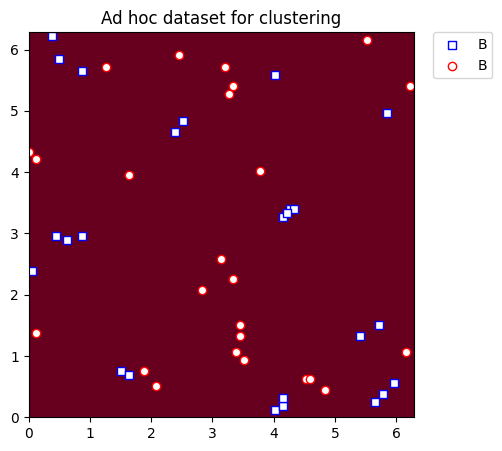

In [12]:
# 군집화 데이터셋을 플롯한다(Plot the clustering dataset)
plt.figure(figsize=(5, 5))
plt.ylim(0, 2 * np.pi)
plt.xlim(0, 2 * np.pi)
plt.imshow(
    np.asmatrix(adhoc_total).T,
    interpolation="nearest",
    origin="lower",
    cmap="RdBu",
    extent=[0, 2 * np.pi, 0, 2 * np.pi],
)

# A label plot
plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "B")

# B label plot
plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.0)
plt.title("Ad hoc dataset for clustering")

plt.show()

### 2.2. 양자 커널 정의하기(Defining the Quantum Kernel)

우리는 분류 예제와 동일한 설정을 사용한다. `zz_feature_map`으로 `FidelityQuantumKernel` 클래스의 또 다른 인스턴스를 생성한다.

In [13]:
# 군집화를 위한 양자 커널을 정의한다(Define quantum kernel for clustering)
adhoc_feature_map = zz_feature_map(feature_dimension=adhoc_dimension, reps=2, entanglement="linear")

adhoc_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=adhoc_feature_map)

### 2.3. 스펙트럼 클러스터링 모델을 사용한 군집화(Clustering with the Spectral Clustering Model)

`scikit-learn` 스펙트럼 클러스터링 알고리즘은 두 가지 방식(`SVC`처럼)으로 커스텀 커널을 정의할 수 있다:

1. **호출 가능한 함수(Callable Function)**로 커널을 제공하여
2. **커널 행렬(Kernel Matrix)**을 사전 계산하여

`qiskit-machine-learning`의 현재 `FidelityQuantumKernel` 클래스로는 후자의 옵션만 사용할 수 있으므로, `evaluate`를 호출하여 커널 행렬을 사전 계산하고 다음과 같이 시각화한다:

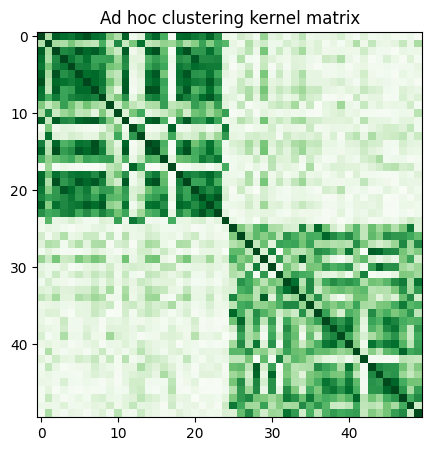

In [14]:
# 커널 행렬을 평가하고 시각화한다(Evaluate and visualize kernel matrix)
adhoc_matrix = adhoc_kernel.evaluate(x_vec=train_features)

plt.figure(figsize=(5, 5))
plt.imshow(np.asmatrix(adhoc_matrix), interpolation="nearest", origin="upper", cmap="Greens")
plt.title("Ad hoc clustering kernel matrix")
plt.show()

다음으로, 우리는 스펙트럼 클러스터링 모델을 정의하고 사전 계산된 커널을 사용하여 이를 적합시킨다. 게다가, 우리는 클래스 라벨을 사전에 알고 있으므로 정규화된 상호 정보(Normalized Mutual Information)를 사용하여 라벨을 점수 매긴다.

In [15]:
# 스펙트럼 클러스터링을 적용한다(Apply spectral clustering)
from sklearn.cluster import SpectralClustering
from sklearn.metrics import normalized_mutual_info_score

adhoc_spectral = SpectralClustering(2, affinity="precomputed")

cluster_labels = adhoc_spectral.fit_predict(adhoc_matrix)

cluster_score = normalized_mutual_info_score(cluster_labels, train_labels)

print(f"Clustering score: {cluster_score}")

Clustering score: 0.7287008798015754


## 3. 커널 주성분 분석(Kernel Principal Component Analysis)

이 섹션은 커널 PCA 알고리즘을 사용한 주성분 분석(Principal Component Analysis) 작업에 초점을 맞춘다. `zz_feature_map`을 사용하여 커널 행렬을 계산하고 이 접근 방식이 원래 특성을 주성분을 따라 선택된 새로운 공간으로 변환함을 보여준다. 이 공간에서 분류 작업은 SVM보다 더 간단한 모델로 수행할 수 있다.

### 3.1. 데이터셋 정의하기(Defining the dataset)

우리는 다시 한 번 두 클래스 사이의 간격이 `0.6`인 _애드혹 데이터셋_을 사용한다. 이 데이터셋은 우리가 군집화 섹션에 있었던 데이터셋과 유사하며, 차이점은 이 경우 `test_size`가 0이 아니라는 것이다.

In [16]:
# PCA를 위한 애드혹 데이터셋을 로드한다(Load ad hoc dataset for PCA)
adhoc_dimension = 2
train_features, train_labels, test_features, test_labels, adhoc_total = ad_hoc_data(
    training_size=25,
    test_size=10,
    n=adhoc_dimension,
    gap=0.6,
    plot_data=False,
    one_hot=False,
    include_sample_total=True,
)

우리는 아래의 학습 및 테스트 데이터셋을 그린다. 이 섹션의 궁극적인 목표는 두 클래스를 선형적으로 분리할 수 있는 새로운 좌표를 구성하는 것이다.

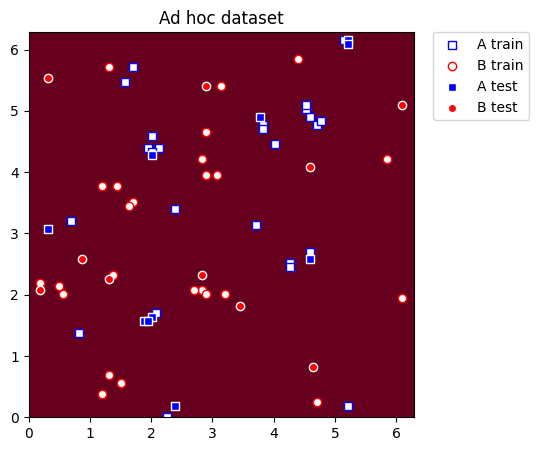

In [17]:
# 학습 및 테스트 데이터셋을 플롯한다(Plot training and test datasets)
plot_dataset(train_features, train_labels, test_features, test_labels, adhoc_total)

### 3.2. 양자 커널 정의하기(Defining the Quantum Kernel)

우리는 분류 작업과 동일한 커널 설정으로 진행한다. 즉, 특성 맵으로서의 `zz_feature_map` 회로와 `FidelityQuantumKernel`의 인스턴스이다.

In [18]:
# PCA를 위한 양자 커널을 정의한다(Define quantum kernel for PCA)
feature_map = zz_feature_map(feature_dimension=2, reps=2, entanglement="linear")
qpca_kernel = FidelityQuantumKernel(fidelity=fidelity, feature_map=feature_map)

그런 다음, 우리는 학습 및 테스트 특성에 대한 커널 행렬을 평가한다.

In [19]:
# 학습 및 테스트 커널 행렬을 평가한다(Evaluate training and test kernel matrices)
matrix_train = qpca_kernel.evaluate(x_vec=train_features)
matrix_test = qpca_kernel.evaluate(x_vec=test_features, y_vec=train_features)

### 3.3. 가우시안 및 양자 커널에 대한 커널 PCA의 비교(Comparison of Kernel PCA on gaussian and quantum kernel)

이 섹션에서 우리는 `scikit-learn`의 `KernelPCA` 구현을 사용하며, `kernel` 파라미터는 가우시안 커널의 경우 "rbf"로 설정되고 양자 커널의 경우 "precomputed"로 설정된다. 전자는 고전 머신 러닝 모델에서 매우 인기가 있으며, 후자는 `qpca_kernel`로 정의된 양자 커널을 사용할 수 있게 한다.

가우시안 커널 기반 커널 PCA 모델이 데이터셋을 선형적으로 분리 가능하게 만드는 데 실패하는 반면, 양자 커널은 성공함을 관찰할 수 있다.

통상적으로 PCA는 데이터셋의 특성 수를 줄이거나, 다시 말해 데이터셋의 차원성을 줄이기 위해 사용되지만, 우리는 여기서 그렇게 하지 않는다. 오히려 차원 수를 유지하고 커널 PCA를 활용하며, 주로 시각화 목적으로 분류 작업이 선형 방법(선형 회귀)으로 쉽게 해결될 수 있음을 보여주기 위해 변환된 데이터셋에서 선택되는 주성분 공간으로 변환된다. 우리는 이 방법을 사용하여 `scikit-learn`의 `LogisticRegression` 모델로 주성분 공간에서 두 클래스를 분리한다. 평소대로 학습 데이터셋에서 `fit` 메서드를 호출하여 훈련하고 `score`로 정확도를 평가한다.

In [20]:
# RBF 및 양자 커널로 커널 PCA를 적용한다(Apply Kernel PCA with RBF and quantum kernels)
from sklearn.decomposition import KernelPCA

kernel_pca_rbf = KernelPCA(n_components=2, kernel="rbf")
kernel_pca_rbf.fit(train_features)
train_features_rbf = kernel_pca_rbf.transform(train_features)
test_features_rbf = kernel_pca_rbf.transform(test_features)

kernel_pca_q = KernelPCA(n_components=2, kernel="precomputed")
train_features_q = kernel_pca_q.fit_transform(matrix_train)
test_features_q = kernel_pca_q.transform(matrix_test)

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


여기서 우리는 모델을 훈련하고 점수를 매긴다.

In [21]:
# 로지스틱 회귀 모델을 훈련하고 점수를 매긴다(Train logistic regression model and score)
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression()
logistic_regression.fit(train_features_q, train_labels)

logistic_score = logistic_regression.score(test_features_q, test_labels)
print(f"Logistic regression score: {logistic_score}")

Logistic regression score: 0.95


결과를 그려보자. 먼저, 우리는 양자 커널로 얻은 변환된 데이터셋을 그린다. 같은 플롯에 모델 결과를 추가한다. 그런 다음, 우리는 가우시안 커널로 얻은 변환된 데이터셋을 그린다.

/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


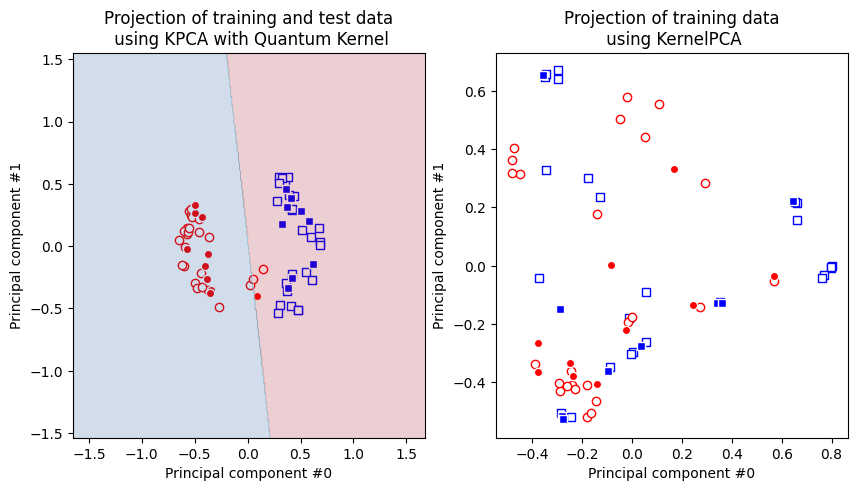

In [22]:
# 변환된 데이터셋과 로지스틱 회귀 결과를 시각화한다(Visualize transformed dataset and logistic regression results)
fig, (q_ax, rbf_ax) = plt.subplots(1, 2, figsize=(10, 5))


plot_features(q_ax, train_features_q, train_labels, 0, "s", "w", "b", "A train")
plot_features(q_ax, train_features_q, train_labels, 1, "o", "w", "r", "B train")

plot_features(q_ax, test_features_q, test_labels, 0, "s", "b", "w", "A test")
plot_features(q_ax, test_features_q, test_labels, 1, "o", "r", "w", "A test")

q_ax.set_ylabel("Principal component #1")
q_ax.set_xlabel("Principal component #0")
q_ax.set_title("Projection of training and test data\n using KPCA with Quantum Kernel")

# Plotting the linear separation
h = 0.01  # step size in the mesh

# create a mesh to plot in
x_min, x_max = train_features_q[:, 0].min() - 1, train_features_q[:, 0].max() + 1
y_min, y_max = train_features_q[:, 1].min() - 1, train_features_q[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

predictions = logistic_regression.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
predictions = predictions.reshape(xx.shape)
q_ax.contourf(xx, yy, predictions, cmap=plt.cm.RdBu, alpha=0.2)

plot_features(rbf_ax, train_features_rbf, train_labels, 0, "s", "w", "b", "A train")
plot_features(rbf_ax, train_features_rbf, train_labels, 1, "o", "w", "r", "B train")
plot_features(rbf_ax, test_features_rbf, test_labels, 0, "s", "b", "w", "A test")
plot_features(rbf_ax, test_features_rbf, test_labels, 1, "o", "r", "w", "A test")

rbf_ax.set_ylabel("Principal component #1")
rbf_ax.set_xlabel("Principal component #0")
rbf_ax.set_title("Projection of training data\n using KernelPCA")
plt.show()

보이는 것처럼, 오른쪽 그림의 데이터 포인트는 분리할 수 없지만, 왼쪽 그림에서는 분리할 수 있으며, 따라서 양자 커널의 경우 변환된 데이터셋에 선형 모델을 적용할 수 있으며, 이것이 바로 우리가 [분류 섹션](#2.-Classification)에서 본 _애드혹_ 데이터셋에서 SVM 분류기가 완벽하게 작동하는 이유이다.

## 4. 결론(Conclusion)

이 튜토리얼에서:

* 양자 커널을 사용한 **스펙트럼 군집화**를 수행하고, 정규화된 상호 정보(NMI)를 사용하여 군집화 품질을 평가했다.
* 양자 커널을 사용한 **커널 PCA**를 수행하고, 가우시안(RBF) 커널과 양자 커널의 차원 축소 결과를 비교했다.
* 양자 커널이 고전적 커널로는 분리하기 어려운 데이터를 효과적으로 변환할 수 있음을 확인했다.

추가 참고를 위해, `scikit-learn`에는 사전 계산된 커널 행렬을 사용할 수 있는 다른 알고리즘들이 있다:

- [응집 클러스터링(Agglomerative clustering)](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)
- [능선 분류기(Ridge classifier)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeClassifier.html)
- [능선 회귀(Ridge regression)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)
- 그 외 많은 알고리즘들

In [1]:
# 버전 정보 및 저작권을 표시한다(Display version information and copyright)
import tutorial_magics

%qiskit_version_table
%qiskit_copyright